# 07 Linalg: Array, Matrix, Vector

TAL linear algebra operates over declared core dimensions while preserving batch and sequence dimensions.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from IPython.display import display

from tal import AnalysisObject
from tal.linalg import Array, Matrix, PInvOptions, Vector, Vector3, dot, norm

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Setup: matrix and vector payloads

`row`, `col`, and vector axes are core dimensions. `sample` is not contracted unless an operation explicitly reduces it.


#### Vector3 velocity

,field,value
0,type,Vector3
1,dims,"{'sample': 41, 'axis': 3}"
2,data_vars,[velocity]
3,coords,"[sample, time_s, axis]"
4,batch_dims,()
5,sequence_dim,sample
6,core_dims,"(axis,)"
7,param_coord,time_s
8,sequence_size_coord,None
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,velocity,"(sample, axis)","(41, 3)",float64
1,coord,sample,"(sample,)","(41,)",int64
2,coord,time_s,"(sample,)","(41,)",float64
3,coord,axis,"(axis,)","(3,)",<U1


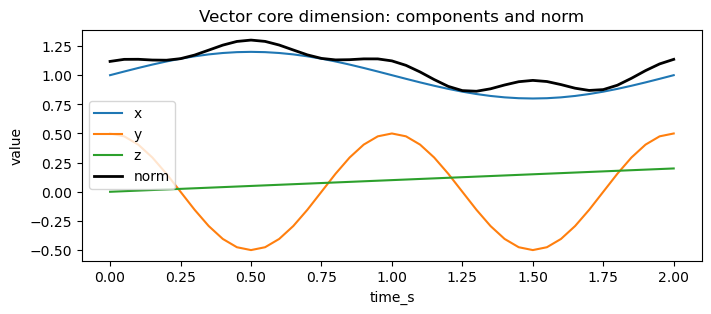

In [2]:
time_s = np.linspace(0.0, 2.0, 41)
velocity_values = np.stack(
    [
        1.0 + 0.2 * np.sin(np.pi * time_s),
        0.5 * np.cos(2.0 * np.pi * time_s),
        0.1 * time_s,
    ],
    axis=-1,
)
velocity_ds = xr.Dataset(
    data_vars={'velocity': (('sample', 'axis'), velocity_values)},
    coords={'sample': np.arange(time_s.size), 'time_s': ('sample', time_s), 'axis': ['x', 'y', 'z']},
)
velocity = Vector3(
    AnalysisObject.from_data(
        velocity_ds,
        sequence_dim='sample',
        core_dims=('axis',),
        param_coord='time_s',
        validate=True,
    )
)
speed = velocity.norm()
velocity_view = velocity.as_dataset(copy='shallow')
speed_view = speed.as_dataset(copy='shallow')

display_result('Vector3 velocity', velocity, data=False)

fig, ax = plt.subplots(figsize=(8, 3))
for component in ['x', 'y', 'z']:
    ax.plot(time_s, velocity_view['velocity'].sel(axis=component), label=component)
ax.plot(time_s, speed_view[next(iter(speed_view.data_vars))], color='black', linewidth=2.0, label='norm')
ax.set(title='Vector core dimension: components and norm', xlabel='time_s', ylabel='value')
ax.legend(loc='best')

A_ds = xr.Dataset(
    data_vars={'A': (('sample', 'row', 'col'), np.array([[[2.0, 1.0], [0.0, 3.0]]], dtype=float))},
    coords={'sample': [0], 'row': ['r0', 'r1'], 'col': ['c0', 'c1']},
)
v_ds = xr.Dataset(
    data_vars={'v': (('sample', 'col'), np.array([[1.0, -1.0]], dtype=float))},
    coords={'sample': [0], 'col': ['c0', 'c1']},
)
rhs_ds = xr.Dataset(
    data_vars={'rhs': (('sample', 'row'), np.array([[3.0, 6.0]], dtype=float))},
    coords={'sample': [0], 'row': ['r0', 'r1']},
)

A = Matrix(AnalysisObject.from_data(A_ds, sequence_dim='sample', core_dims=('row', 'col'), validate=True))
v = Vector(AnalysisObject.from_data(v_ds, sequence_dim='sample', core_dims=('col',), validate=True))
rhs = Vector(AnalysisObject.from_data(rhs_ds, sequence_dim='sample', core_dims=('row',), validate=True))


## Semantic contraction

Matrix multiplication, solves, inverses, dot products, and norms use declared core dimensions instead of positional axis guesses.


,result,type,dims
0,A @ v,Vector,"{'sample': 1, 'row': 2}"
1,A.solve(rhs),Vector,"{'sample': 1, 'col': 2}"
2,A.inv(),Matrix,"{'sample': 1, 'row': 2, 'col': 2}"
3,A.pinv(),Matrix,"{'sample': 1, 'row': 2, 'col': 2}"
4,"dot(v, v)",Array,{'sample': 1}
5,norm(v),Array,{'sample': 1}


#### solution vector

,field,value
0,type,Vector
1,dims,"{'sample': 1, 'col': 2}"
2,data_vars,[datavar]
3,coords,"[sample, col]"
4,batch_dims,()
5,sequence_dim,sample
6,core_dims,"(col,)"
7,param_coord,None
8,sequence_size_coord,None
9,frames,None


<xarray.Dataset> Size: 40B
Dimensions:  (sample: 1, col: 2)
Coordinates:
  * sample   (sample) int64 8B 0
  * col      (col) <U2 16B 'c0' 'c1'
Data variables:
    datavar  (sample, col) float64 16B 0.5 2.0
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': [], 'core_dims'...

[Text(0.5, 1.0, 'Matrix payload checkpoint: covariance trace over time'),
 Text(0.5, 0, 'time_s'),
 Text(0, 0.5, 'trace')]

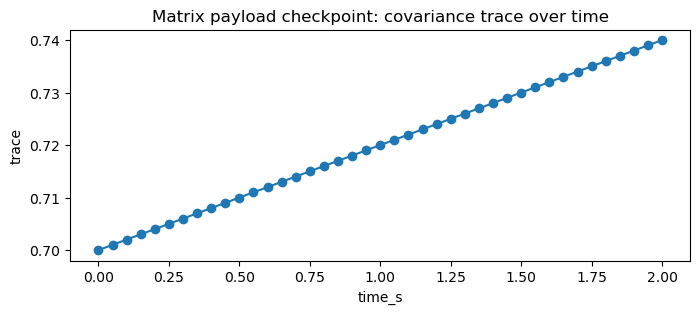

In [3]:
Av = A @ v
x = A.solve(rhs)
A_inv = A.inv()
A_pinv = A.pinv(opts=PInvOptions(rcond=1e-8))
v_dot_v = dot(v, v)
v_norm = norm(v, ord=2)

display(
    pd.DataFrame(
        [
            {'result': 'A @ v', 'type': type(Av).__name__, 'dims': dict(Av.as_dataset().sizes)},
            {'result': 'A.solve(rhs)', 'type': type(x).__name__, 'dims': dict(x.as_dataset().sizes)},
            {'result': 'A.inv()', 'type': type(A_inv).__name__, 'dims': dict(A_inv.as_dataset().sizes)},
            {'result': 'A.pinv()', 'type': type(A_pinv).__name__, 'dims': dict(A_pinv.as_dataset().sizes)},
            {'result': 'dot(v, v)', 'type': type(v_dot_v).__name__, 'dims': dict(v_dot_v.as_dataset().sizes)},
            {'result': 'norm(v)', 'type': type(v_norm).__name__, 'dims': dict(v_norm.as_dataset().sizes)},
        ]
    )
)
display_result('solution vector', x, data=True)

cov_t = np.linspace(0.0, 2.0, 41)
cov_values = np.zeros((cov_t.size, 2, 2), dtype=float)
cov_values[:, 0, 0] = 0.2 + 0.1 * cov_t
cov_values[:, 1, 1] = 0.5 - 0.08 * cov_t
cov_values[:, 0, 1] = cov_values[:, 1, 0] = 0.04 * np.sin(np.pi * cov_t)
cov_ds = xr.Dataset(
    data_vars={'covariance': (('sample', 'row', 'col'), cov_values)},
    coords={'sample': np.arange(cov_t.size), 'time_s': ('sample', cov_t), 'row': ['x', 'y'], 'col': ['x', 'y']},
)
cov = Matrix(AnalysisObject.from_data(cov_ds, sequence_dim='sample', core_dims=('row', 'col'), param_coord='time_s'))
cov_view = cov.as_dataset(copy='shallow')
trace = cov_view['covariance'].sel(row='x', col='x') + cov_view['covariance'].sel(row='y', col='y')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(cov_t, trace, marker='o')
ax.set(title='Matrix payload checkpoint: covariance trace over time', xlabel='time_s', ylabel='trace')


What to notice

The core dimensions are consumed or produced by the math operation. The sequence dimension remains attached.


## General `Array` wrapper

Use `Array` when you need to assign or refine mathematical meaning for core axes before calling higher-level operations.


In [4]:
arr_vec = Array(AnalysisObject.from_data(v_ds.rename({'v': 'x'}), sequence_dim='sample', core_dims=('col',), validate=True))
arr_mat = Array(AnalysisObject.from_data(A_ds.rename({'A': 'x'}), sequence_dim='sample', core_dims=('row', 'col'), validate=True))

arr_vec_axis = arr_vec.axis('col')
arr_mat_rc = arr_mat.rc('row', 'col')

arr_vec_axis.as_dataset().attrs['tal']['core']['roles'], arr_mat_rc.as_dataset().attrs['tal']['core']['roles']


({'batch_dims': [], 'core_dims': ['col'], 'sequence_dim': 'sample'},
 {'batch_dims': [], 'core_dims': ['row', 'col'], 'sequence_dim': 'sample'})

## Takeaways

- Core dims are payload axes.
- Batch/sequence dims are carried through linalg operations.
- Method and functional styles share the same semantic alignment model.

**Exercise:** add a second sample to `A_ds` and `v_ds`; confirm the linalg outputs keep `sample`.
